# DressMe — Data Understanding
**Personal Fashion Assistant · Advanced Data Science Project**

Ce notebook explore cinq sources de données et évalue leur utilité pour chaque fonctionnalité de DressMe.

| # | Source | Rôle principal |
|---|---|---|
| 1 | Fashion Product Images (Kaggle) | Attributs : catégorie, couleur, saison, usage (F1, F2, F3, F8) |
| 2 | iMaterialist Fashion 2020 (FGVC7) | Détection / segmentation de vêtements sur personnes |
| 3 | Polyvore (xthan) | Compatibilité et complétion de tenues (F4, F5, F7) |
| 4 | DigiKlothes | Images non labellisées + prix (e-commerce iranien) |
| 5 | Catalogue HA (Tunisie) | Validation locale (scraping, à vérifier légalement) |
| 6 | Sanity check CLIP (optionnel) | Similarité (F8) et zero-shot sur Fashion Product |

**Utilisation** : activez/désactivez chaque section dans le dictionnaire `RUN` de la cellule de configuration. Chaque section est indépendante et tolère l'absence des autres datasets.

## 0. Configuration et utilitaires

In [ ]:
# !pip install -q kagglehub pandas numpy matplotlib seaborn pillow scikit-learn tqdm requests beautifulsoup4 transformers torch

import os, json, glob, re, ast, random, warnings, subprocess, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
random.seed(42); np.random.seed(42)

# ---- Activer / désactiver les sections ----
RUN = dict(
    fashion=True,       # Section 1
    imat=True,          # Section 2 (gros téléchargement, ~20 Go)
    polyvore=True,      # Section 3 (nécessite le dossier de données Polyvore)
    digiklothes=True,   # Section 4
    ha=False,           # Section 5 (scraping : vérifier d'abord CGU / robots.txt)
    clip=False,         # Section 6 (nécessite torch + transformers, GPU conseillé)
)

SAMPLE_N = 500          # taille des échantillons pour les analyses d'images
POLYVORE_DIR = "./polyvore_data"     # dossier contenant les JSON + images Polyvore
DIGI_DIR = "./DigiKlothes"           # dossier du dépôt cloné
HA_URL = "https://ha.com.tn/catalogue/"

SUMMARY = {}   # résumé alimenté au fil du notebook

def show_grid(paths, titles=None, ncols=5, size=(3, 3.2), suptitle=None):
    n = len(paths); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size[0], nrows * size[1]))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes: ax.axis("off")
    for i, p in enumerate(paths):
        try:
            axes[i].imshow(Image.open(p).convert("RGB"))
            if titles is not None: axes[i].set_title(str(titles[i])[:30], fontsize=8)
        except Exception:
            axes[i].set_title("erreur", fontsize=8)
    if suptitle: fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()

def barh_counts(s, title, top=20):
    vc = s.value_counts(dropna=False).head(top)
    plt.figure(figsize=(7, 0.32 * len(vc) + 1.5))
    sns.barplot(x=vc.values, y=vc.index.astype(str), color="steelblue")
    plt.title(title); plt.xlabel("effectif"); plt.tight_layout(); plt.show()

---
## 1. Fashion Product Images Dataset (Kaggle)

**Questions à traiter** : structure, qualité (valeurs manquantes, lignes corrompues, images absentes), distribution des labels, déséquilibre, cohérence images/labels, et pertinence pour une garde-robe réelle.

### 1.1 Téléchargement et localisation des fichiers

In [ ]:
if RUN["fashion"]:
    import kagglehub
    FP_PATH = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")
    print("Path:", FP_PATH)
    cands = glob.glob(os.path.join(FP_PATH, "**", "styles.csv"), recursive=True)
    assert cands, "styles.csv introuvable"
    STYLES_CSV = cands[0]
    FP_ROOT = os.path.dirname(STYLES_CSV)
    IMG_DIR = os.path.join(FP_ROOT, "images")
    print("Racine:", FP_ROOT)
    print("Contenu:", os.listdir(FP_ROOT))

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Path: /kaggle/input/fashion-product-images-dataset
Racine: /kaggle/input/fashion-product-images-dataset/fashion-dataset
Contenu: ['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


### 1.2 Chargement et lignes corrompues

In [ ]:
if RUN["fashion"]:
    with open(STYLES_CSV, encoding="utf-8") as f:
        n_lines = sum(1 for _ in f) - 1
    styles = pd.read_csv(STYLES_CSV, on_bad_lines="skip")
    print(f"Lignes dans le fichier : {n_lines} | lignes lues : {len(styles)} | ignorées : {n_lines - len(styles)}")
    print(styles.dtypes)
    display(styles.head())

Lignes dans le fichier : 44446 | lignes lues : 44424 | ignorées : 22
id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
dtype: object


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


### 1.3 Qualité des données

In [ ]:
if RUN["fashion"]:
    # Images disponibles
    styles["file"] = styles["id"].astype(str) + ".jpg"
    existing = set(os.listdir(IMG_DIR))
    styles["has_image"] = styles["file"].isin(existing)
    orphan = existing - set(styles["file"])
    print(f"Images dans le dossier : {len(existing)}")
    print(f"Produits sans image    : {(~styles['has_image']).sum()}")
    print(f"Images sans produit    : {len(orphan)}")

    # Valeurs manquantes
    miss = styles.drop(columns=["file", "has_image"]).isna().mean().mul(100).round(2).sort_values(ascending=False)
    print("\n% valeurs manquantes :\n", miss)

    # Doublons
    print("\nId dupliqués :", styles["id"].duplicated().sum())
    print("Noms dupliqués :", styles["productDisplayName"].duplicated().sum())
    print("\nCardinalités :\n", styles.nunique())

Images dans le dossier : 44441
Produits sans image    : 5
Images sans produit    : 22

% valeurs manquantes :
 usage                 0.71
season                0.05
baseColour            0.03
productDisplayName    0.02
gender                0.00
id                    0.00
articleType           0.00
subCategory           0.00
masterCategory        0.00
year                  0.00
dtype: float64

Id dupliqués : 0
Noms dupliqués : 13302

Cardinalités :
 id                    44424
gender                    5
masterCategory            7
subCategory              45
articleType             143
baseColour               46
season                    4
year                     13
usage                     8
productDisplayName    31121
file                  44424
has_image                 2
dtype: int64


### 1.4 Distributions des variables clés

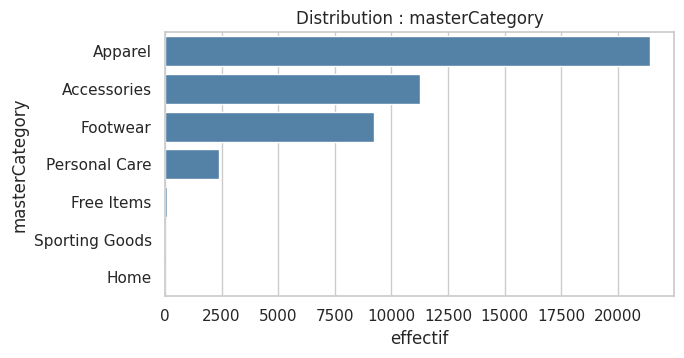

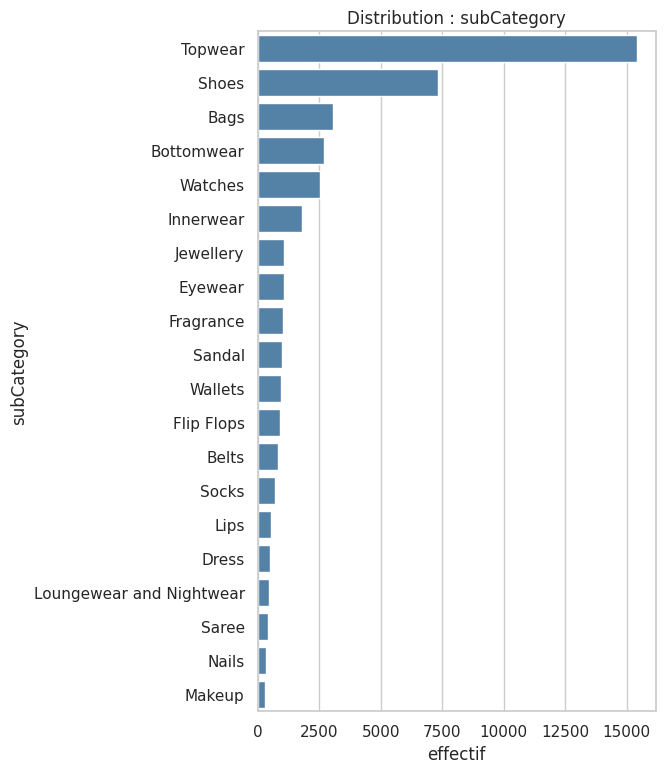

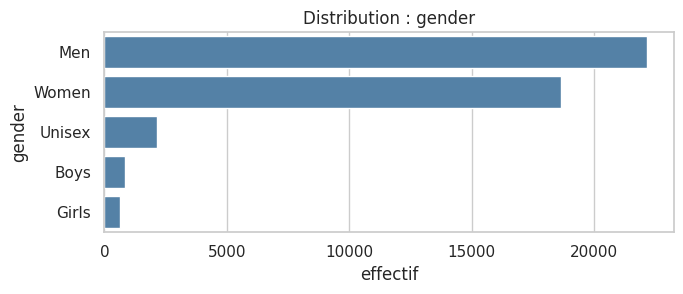

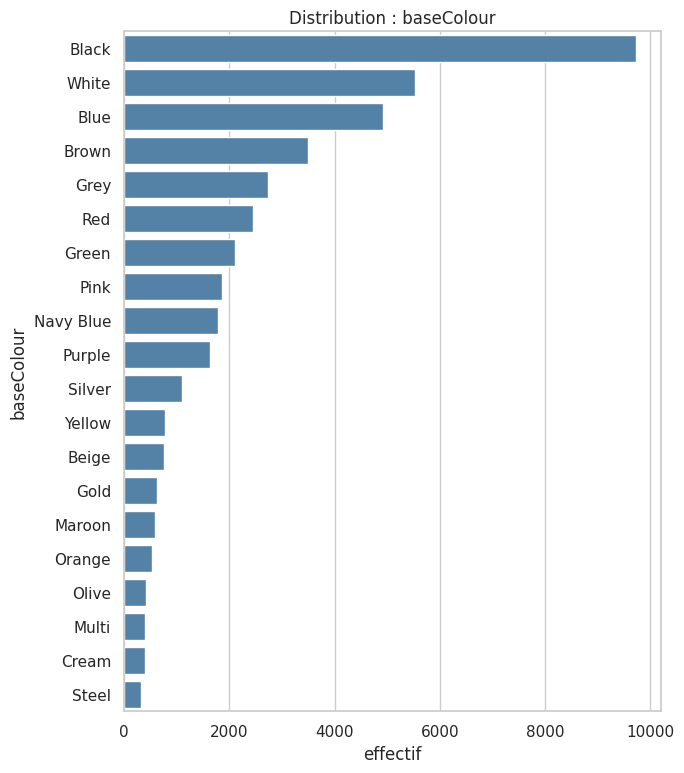

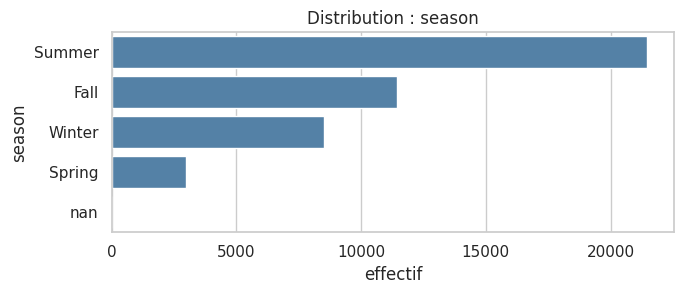

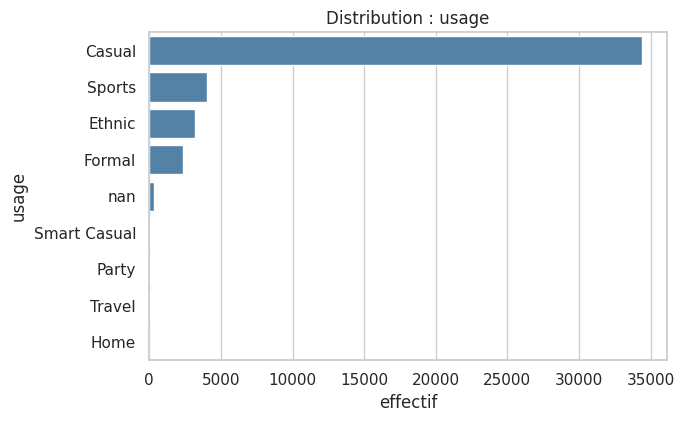

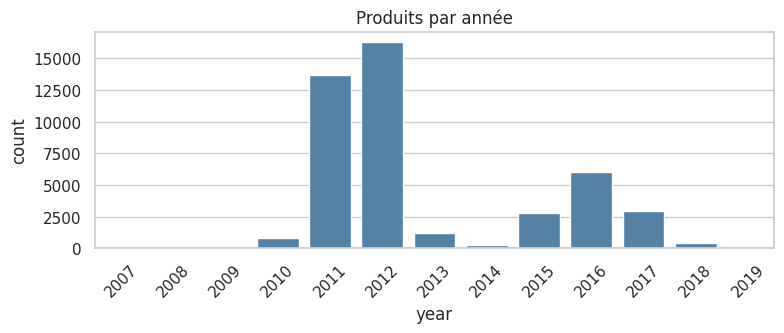

In [ ]:
if RUN["fashion"]:
    for col in ["masterCategory", "subCategory", "gender", "baseColour", "season", "usage"]:
        barh_counts(styles[col], f"Distribution : {col}", top=20)

    plt.figure(figsize=(8, 3.5))
    sns.countplot(x="year", data=styles.dropna(subset=["year"]).astype({"year": int}), color="steelblue")
    plt.title("Produits par année"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 1.5 Déséquilibre et longue traîne (`articleType`)

143 articleType | <100 ex. : 89 | <30 ex. : 59
Top 10 = 57.3% du dataset

Top 30 :
 articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Nail Polish               329
Lipstick                  315
Name

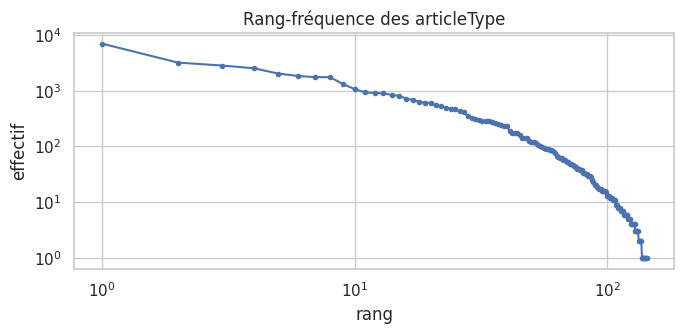

In [ ]:
if RUN["fashion"]:
    vc = styles["articleType"].value_counts()
    print(f"{len(vc)} articleType | <100 ex. : {(vc<100).sum()} | <30 ex. : {(vc<30).sum()}")
    print(f"Top 10 = {vc.head(10).sum()/len(styles):.1%} du dataset")
    print("\nTop 30 :\n", vc.head(30))

    plt.figure(figsize=(7, 3.5))
    plt.loglog(range(1, len(vc) + 1), vc.values, marker=".")
    plt.xlabel("rang"); plt.ylabel("effectif"); plt.title("Rang-fréquence des articleType")
    plt.tight_layout(); plt.show()

### 1.6 Relations entre variables

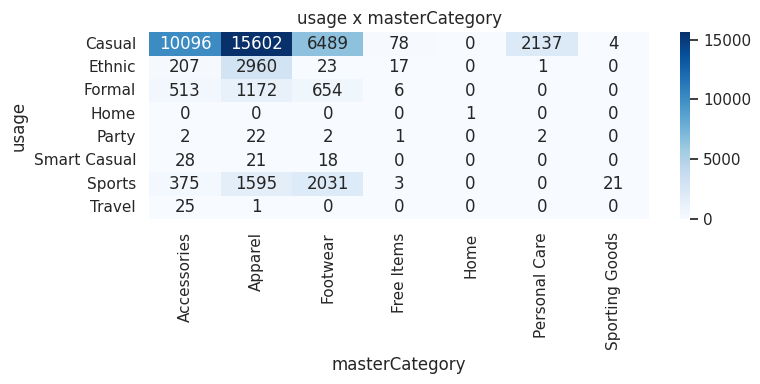

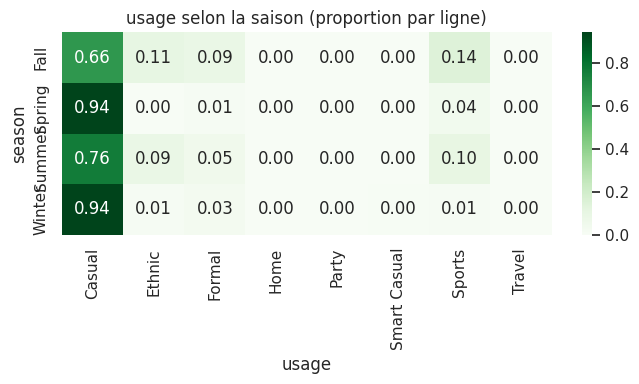

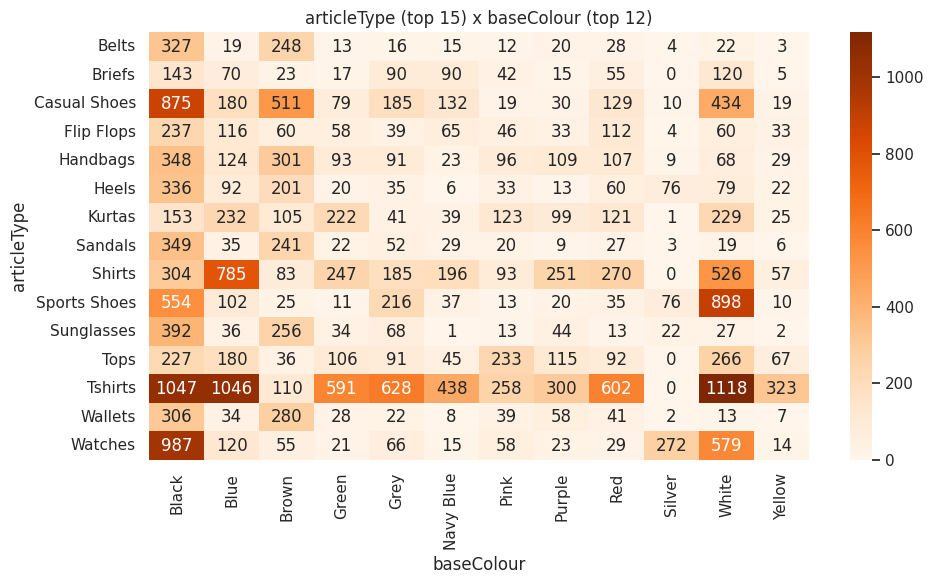

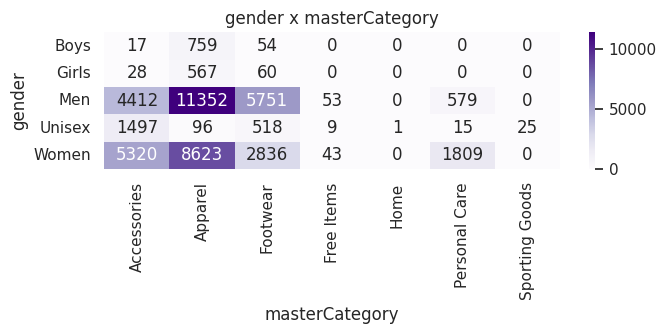

In [ ]:
if RUN["fashion"]:
    # usage x masterCategory
    plt.figure(figsize=(8, 4))
    sns.heatmap(pd.crosstab(styles["usage"], styles["masterCategory"]), annot=True, fmt="d", cmap="Blues")
    plt.title("usage x masterCategory"); plt.tight_layout(); plt.show()

    # saison x usage
    plt.figure(figsize=(7, 4))
    sns.heatmap(pd.crosstab(styles["season"], styles["usage"], normalize="index"), annot=True, fmt=".2f", cmap="Greens")
    plt.title("usage selon la saison (proportion par ligne)"); plt.tight_layout(); plt.show()

    # couleur x articleType (top)
    top_art = styles["articleType"].value_counts().head(15).index
    top_col = styles["baseColour"].value_counts().head(12).index
    ct = pd.crosstab(styles.loc[styles.articleType.isin(top_art), "articleType"],
                     styles.loc[styles.baseColour.isin(top_col), "baseColour"])
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Oranges")
    plt.title("articleType (top 15) x baseColour (top 12)"); plt.tight_layout(); plt.show()

    # genre x categorie
    plt.figure(figsize=(7, 3.5))
    sns.heatmap(pd.crosstab(styles["gender"], styles["masterCategory"]), annot=True, fmt="d", cmap="Purples")
    plt.title("gender x masterCategory"); plt.tight_layout(); plt.show()

### 1.7 Texte (`productDisplayName`)

Longueur moyenne (mots) : 5.79
Mots les plus fréquents : [('black', 9678), ('shirt', 7599), ('blue', 6596), ('white', 5803), ('shoes', 4087), ('printed', 3437), ('brown', 3242), ('red', 3102), ('grey', 3044), ('watch', 2413), ('nike', 2326), ('green', 2320), ('casual', 2297), ('puma', 2102), ('adidas', 2081), ('unisex', 2033), ('navy', 1844), ('pink', 1765), ('dial', 1743), ('kurta', 1688), ('polo', 1656), ('top', 1588), ('purple', 1561), ('united', 1513), ('sports', 1465)]


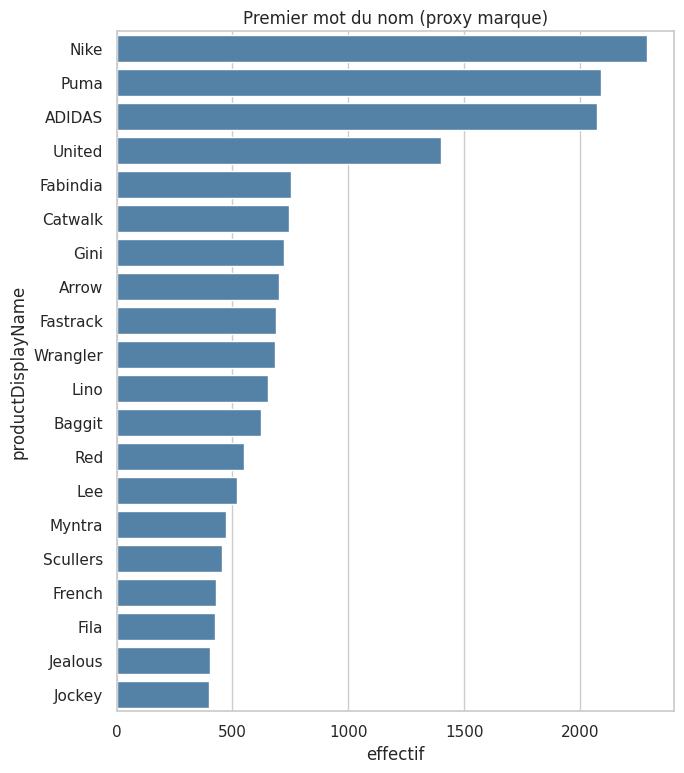

In [ ]:
if RUN["fashion"]:
    names = styles["productDisplayName"].dropna().astype(str)
    print("Longueur moyenne (mots) :", names.str.split().str.len().mean().round(2))
    stop = {"for", "and", "the", "with", "of", "men", "women", "boys", "girls", "pack", "set", "a"}
    words = collections.Counter(w.lower() for n in names for w in re.findall(r"[A-Za-z]+", n) if w.lower() not in stop and len(w) > 2)
    print("Mots les plus fréquents :", words.most_common(25))

    brands = names.str.split().str[0]
    barh_counts(brands, "Premier mot du nom (proxy marque)", top=20)

### 1.8 Périmètre « garde-robe » : regroupement en *slots* de tenue
DressMe a besoin de savoir **quelle place** occupe une pièce dans une tenue (haut, bas, chaussures, sac…).
On construit ici un mapping `slot` à partir de `subCategory` / `articleType`.

slot
top             15092
shoes            9219
accessory        6684
other            3120
bag              3055
bottom           2694
out_of_scope     2534
one_piece         905
belt              811
outerwear         310
Name: count, dtype: int64

Périmètre garde-robe (hors out_of_scope/other) : 87.3%

articleType classés 'other' :
 articleType
Briefs              849
Socks               686
Bra                 477
Innerwear Vests     242
Nightdress          189
Night suits         141
Trunk               140
Kurta Sets           94
Lounge Pants         61
Boxers               52
Camisoles            39
Lounge Shorts        34
Shoe Accessories     23
Bath Robe            20
Baby Dolls           16
Name: count, dtype: int64


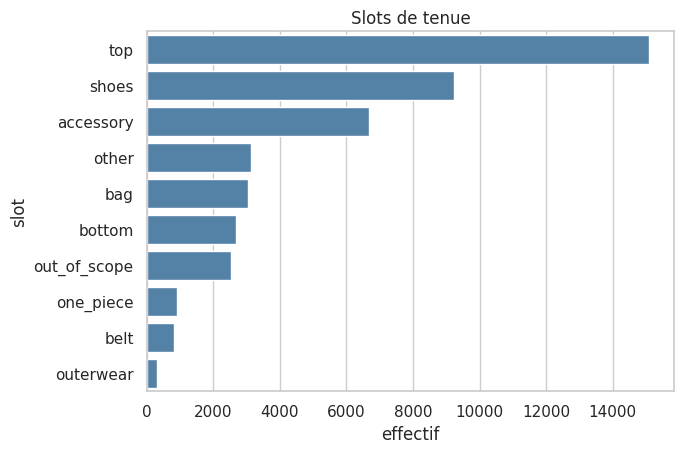

           articleType  baseColour  usage
slot                                     
bag                 13          39      6
bottom              17          33      5
outerwear            6          21      5
shoes                8          40      6
top                 15          39      6


In [ ]:
if RUN["fashion"]:
    OUTER = {"Jackets", "Blazers", "Coat", "Coats", "Waistcoat", "Rain Jacket", "Nehru Jackets", "Shrug", "Capris_dummy"}
    ACCESSORY_SUB = {"Watches", "Jewellery", "Eyewear", "Headwear", "Scarves", "Ties", "Gloves", "Mufflers",
                     "Stoles", "Cufflinks", "Wallets", "Accessories", "Sports Accessories"}
    def to_slot(r):
        a, s, m = r["articleType"], r["subCategory"], r["masterCategory"]
        if m not in ("Apparel", "Footwear", "Accessories"): return "out_of_scope"
        if a in OUTER: return "outerwear"
        if s == "Topwear": return "top"
        if s == "Bottomwear": return "bottom"
        if s in ("Dress", "Saree"): return "one_piece"
        if s in ("Shoes", "Flip Flops", "Sandal"): return "shoes"
        if s == "Bags": return "bag"
        if s == "Belts": return "belt"
        if s in ACCESSORY_SUB: return "accessory"
        return "other"

    styles["slot"] = styles.apply(to_slot, axis=1)
    print(styles["slot"].value_counts())
    print(f"\nPérimètre garde-robe (hors out_of_scope/other) : "
          f"{styles['slot'].isin(['top','bottom','outerwear','one_piece','shoes','bag','belt','accessory']).mean():.1%}")
    print("\narticleType classés 'other' :\n", styles.loc[styles.slot == "other", "articleType"].value_counts().head(15))
    barh_counts(styles["slot"], "Slots de tenue", top=12)

    # Couverture par slot : combien de types / couleurs / usages
    print(styles[styles.slot.isin(["top","bottom","outerwear","shoes","bag"])]
          .groupby("slot")[["articleType", "baseColour", "usage"]].nunique())

### 1.9 Analyse des images

Lecture images:   0%|          | 0/500 [00:00<?, ?it/s]

             w        h   ratio
count   500.00   500.00  500.00
mean   1399.27  1866.28    0.75
std     362.33   483.94    0.00
min     150.00   200.00    0.67
25%    1080.00  1440.00    0.75
50%    1080.00  1440.00    0.75
75%    1800.00  2400.00    0.75
max    1806.00  2700.00    0.75
Images à fond quasi blanc : 98.4%


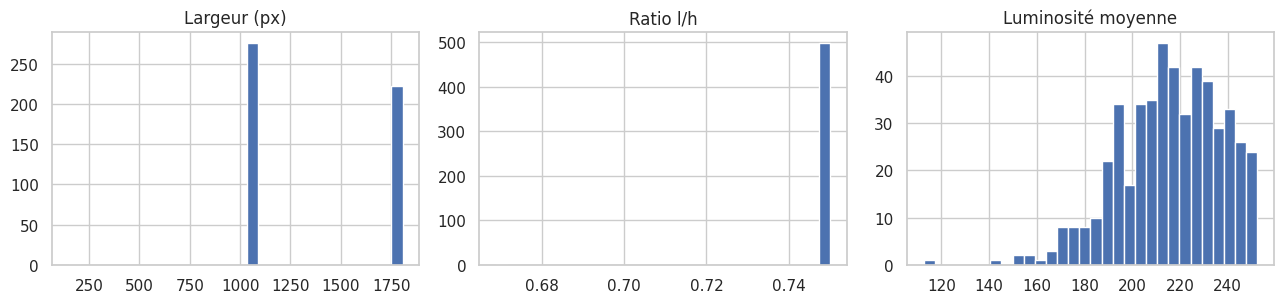

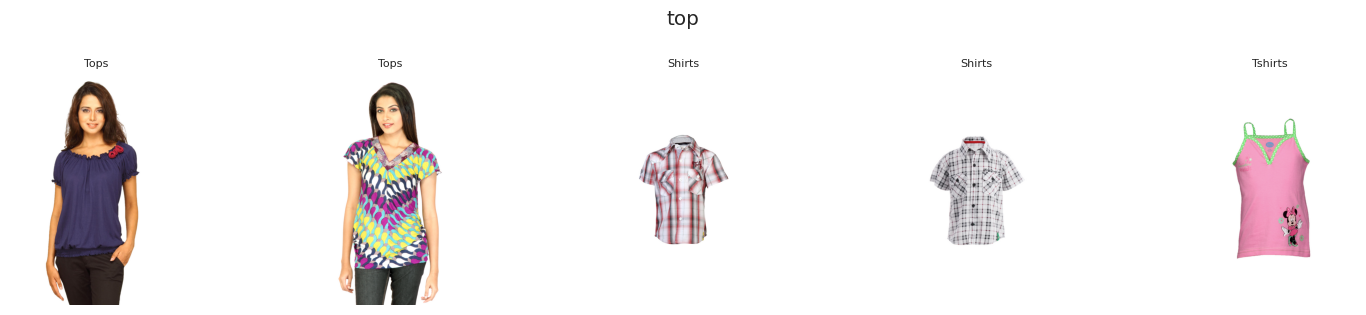

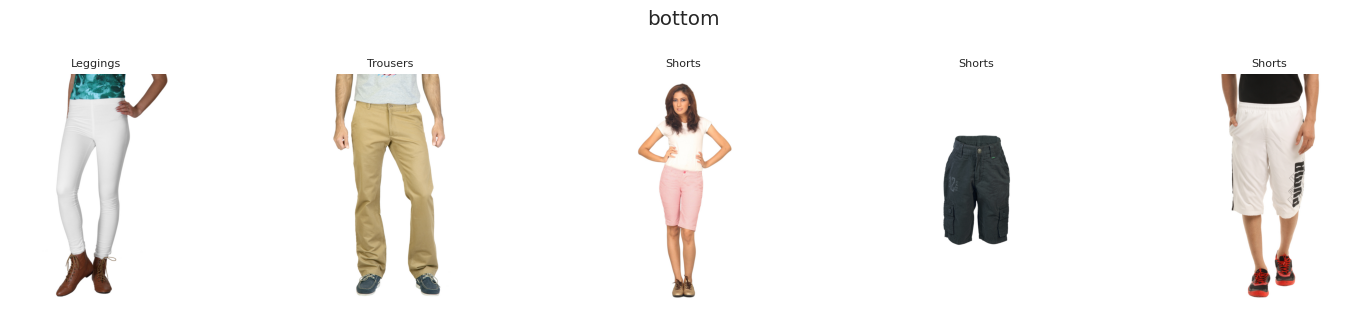

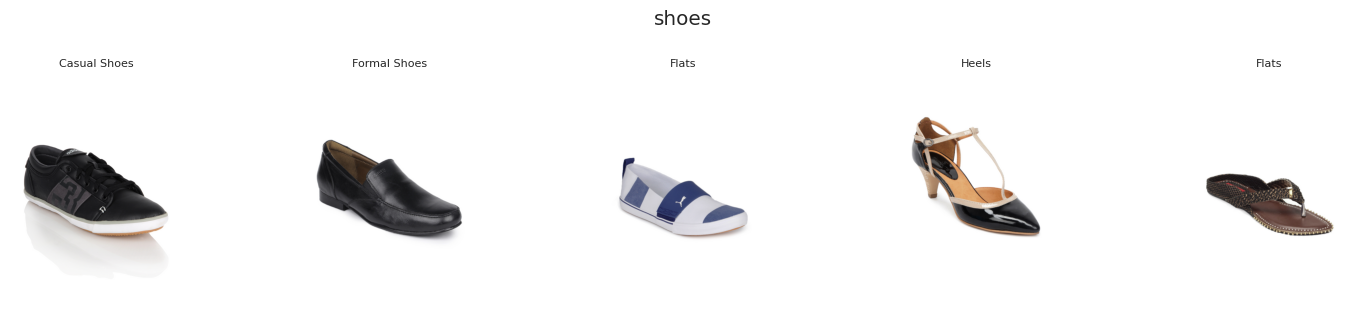

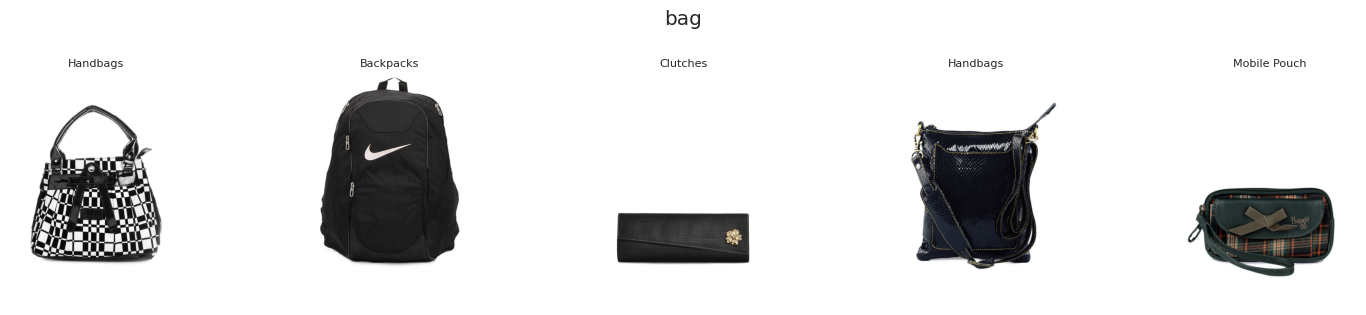

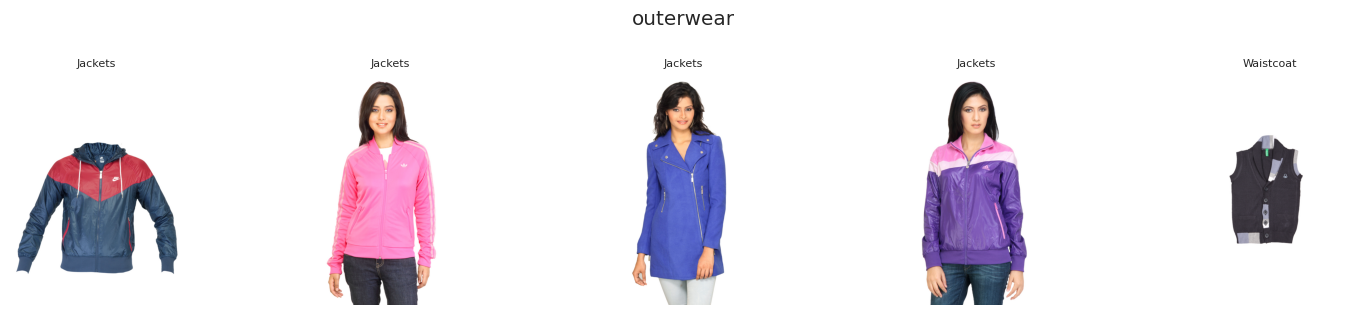

In [ ]:
if RUN["fashion"]:
    ok = styles[styles.has_image]
    sample = ok.sample(min(SAMPLE_N, len(ok)), random_state=42)

    sizes, brightness, bg_white = [], [], []
    for f in tqdm(sample["file"], desc="Lecture images"):
        try:
            im = Image.open(os.path.join(IMG_DIR, f)).convert("RGB")
            sizes.append(im.size)
            a = np.asarray(im.resize((64, 64))).astype(float)
            brightness.append(a.mean())
            corners = np.concatenate([a[:4, :4].reshape(-1, 3), a[:4, -4:].reshape(-1, 3),
                                      a[-4:, :4].reshape(-1, 3), a[-4:, -4:].reshape(-1, 3)])
            bg_white.append(corners.min(axis=1).mean() > 235)
        except Exception:
            pass
    sz = pd.DataFrame(sizes, columns=["w", "h"]); sz["ratio"] = sz.w / sz.h
    print(sz.describe().round(2))
    print(f"Images à fond quasi blanc : {np.mean(bg_white):.1%}")

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
    sz["w"].hist(ax=ax[0], bins=30); ax[0].set_title("Largeur (px)")
    sz["ratio"].hist(ax=ax[1], bins=30); ax[1].set_title("Ratio l/h")
    pd.Series(brightness).hist(ax=ax[2], bins=30); ax[2].set_title("Luminosité moyenne")
    plt.tight_layout(); plt.show()

    # Grille d'exemples par slot
    for slot in ["top", "bottom", "shoes", "bag", "outerwear"]:
        sub = ok[ok.slot == slot].sample(5, random_state=1)
        show_grid([os.path.join(IMG_DIR, f) for f in sub.file], sub["articleType"].tolist(), ncols=5, suptitle=slot)

### 1.10 Cohérence labels / pixels (couleur)

Couleurs:   0%|          | 0/1000 [00:00<?, ?it/s]

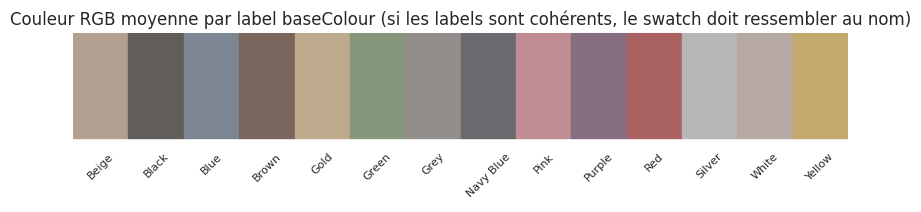

In [ ]:
if RUN["fashion"]:
    def mean_rgb_nonbg(path, thr=235, size=64):
        a = np.asarray(Image.open(path).convert("RGB").resize((size, size))).reshape(-1, 3).astype(float)
        m = a.min(axis=1) <= thr          # on ignore le fond blanc
        return a[m].mean(axis=0) if m.sum() > 20 else np.array([np.nan] * 3)

    cs = ok[ok.baseColour.isin(ok.baseColour.value_counts().head(14).index)].sample(min(SAMPLE_N * 2, len(ok)), random_state=3)
    rgb = np.array([mean_rgb_nonbg(os.path.join(IMG_DIR, f)) for f in tqdm(cs.file, desc="Couleurs")])
    cs = cs.assign(r=rgb[:, 0], g=rgb[:, 1], b=rgb[:, 2]).dropna(subset=["r"])
    avg = cs.groupby("baseColour")[["r", "g", "b"]].mean()

    fig, ax = plt.subplots(figsize=(10, 2.2))
    for i, (name, row) in enumerate(avg.iterrows()):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=row.values / 255))
        ax.text(i + 0.5, -0.12, name, ha="center", va="top", rotation=45, fontsize=8)
    ax.set_xlim(0, len(avg)); ax.set_ylim(-0.6, 1); ax.axis("off")
    ax.set_title("Couleur RGB moyenne par label baseColour (si les labels sont cohérents, le swatch doit ressembler au nom)")
    plt.show()

In [ ]:
if RUN["fashion"]:
    SUMMARY["fashion_product"] = dict(
        n_rows=int(len(styles)), n_bad_lines=int(n_lines - len(styles)),
        n_missing_images=int((~styles.has_image).sum()),
        n_articleTypes=int(styles.articleType.nunique()),
        n_colors=int(styles.baseColour.nunique()),
        in_wardrobe_scope_pct=float(styles['slot'].isin(['top','bottom','outerwear','one_piece','shoes','bag','belt','accessory']).mean()),
    )
    print(SUMMARY["fashion_product"])

{'n_rows': 44424, 'n_bad_lines': 22, 'n_missing_images': 5, 'n_articleTypes': 143, 'n_colors': 46, 'in_wardrobe_scope_pct': 0.8727264541689177}


**À retenir (à compléter avec vos résultats)**
- Fichier `styles.csv` : lignes corrompues à ignorer → noter le nombre exact.
- Déséquilibre fort des `articleType` : prévoir regroupement ou pondération.
- Photos de studio sur fond blanc ≠ photos d'utilisateur : prévoir augmentation / test sur vos propres photos.
- Pas d'info de **style** direct : `usage` (Casual, Formal, Sports…) est le meilleur proxy.
- Le `slot` calculé ici servira de base aux règles de complétion de tenue.

---
## 2. iMaterialist Fashion 2020 (FGVC7)

Segmentation + attributs sur des photos de personnes. **Attention** : téléchargement volumineux et acceptation préalable des règles de la compétition sur Kaggle.

In [ ]:
if RUN["imat"]:
    import kagglehub
    COMP = "imaterialist-fashion-2020-fgvc7"
    DOWNLOAD_ALL = False   # True = tout télécharger (~20 Go), seulement pour visualiser les masques

    try:
        kagglehub.login()   # ignoré si KAGGLE_USERNAME / KAGGLE_KEY sont déjà définis
        if DOWNLOAD_ALL:
            IMAT_PATH = kagglehub.competition_download(COMP)
            TRAIN_CSV = glob.glob(os.path.join(IMAT_PATH, "**", "train.csv"), recursive=True)[0]
            LABEL_JSON = glob.glob(os.path.join(IMAT_PATH, "**", "label_descriptions.json"), recursive=True)[0]
            TRAIN_IMG_DIR = os.path.join(os.path.dirname(TRAIN_CSV), "train")
        else:
            TRAIN_CSV = kagglehub.competition_download(COMP, path="train.csv")
            LABEL_JSON = kagglehub.competition_download(COMP, path="label_descriptions.json")
            TRAIN_IMG_DIR = None
        print(TRAIN_CSV, LABEL_JSON, TRAIN_IMG_DIR, sep="\n")
    except Exception as e:
        print("Échec du téléchargement :", type(e).__name__, e)
        print("Vérifiez : 1) règles de la compétition acceptées, 2) token Kaggle valide.")
        RUN["imat"] = False   # désactive le reste de la section 2

Échec du téléchargement : UnauthenticatedError User is not authenticated
Vérifiez : 1) règles de la compétition acceptées, 2) token Kaggle valide.


### 2.1 Description des labels

In [ ]:
if RUN["imat"]:
    with open(LABEL_JSON) as f: lab = json.load(f)
    print("Clés :", lab.keys())
    cats = pd.DataFrame(lab["categories"]); attrs = pd.DataFrame(lab["attributes"])
    print(f"{len(cats)} catégories | {len(attrs)} attributs")
    display(cats.head(50))
    print(attrs["supercategory"].value_counts())
    display(attrs.head(20))

### 2.2 Chargement de `train.csv`

In [ ]:
if RUN["imat"]:
    imat = pd.read_csv(TRAIN_CSV)
    print(imat.shape); print(imat.dtypes)
    display(imat.head())
    imat["cls"] = imat["ClassId"].astype(str).str.split("_").str[0].astype(int)
    imat["n_attr"] = imat["AttributesIds"].fillna("").apply(lambda s: len([x for x in str(s).split(",") if x.strip()]))
    cat_name = dict(zip(cats.id, cats.name))
    imat["cls_name"] = imat["cls"].map(cat_name)

    print("Images uniques :", imat.ImageId.nunique())
    print("Instances       :", len(imat))
    print("Valeurs manquantes (%):\n", imat.isna().mean().mul(100).round(2))

### 2.3 Statistiques : instances par image, classes, attributs, taille des masques

In [ ]:
if RUN["imat"]:
    per_img = imat.groupby("ImageId").size()
    print("Vêtements par image :\n", per_img.describe().round(2))
    plt.figure(figsize=(6, 3)); per_img.hist(bins=range(1, int(per_img.max()) + 2)); plt.title("Instances par image"); plt.show()

    barh_counts(imat["cls_name"], "Classes (instances)", top=46)

    plt.figure(figsize=(6, 3)); imat["n_attr"].hist(bins=range(0, int(imat.n_attr.max()) + 2))
    plt.title("Attributs par instance"); plt.show()
    print(f"Instances sans attribut : {(imat.n_attr == 0).mean():.1%}")

    # fréquence des attributs
    att_ids = imat["AttributesIds"].dropna().astype(str).str.split(",").explode().str.strip()
    att_ids = att_ids[att_ids != ""].astype(int)
    att_name = dict(zip(attrs.id, attrs.name))
    att_vc = att_ids.map(att_name).value_counts()
    print(f"Attributs utilisés : {att_vc.shape[0]} / {len(attrs)} | rares (<50) : {(att_vc < 50).sum()}")
    barh_counts(att_ids.map(att_name), "Attributs les plus fréquents", top=25)

    # aire relative du masque (sans décoder : somme des longueurs de runs)
    def mask_ratio(r):
        s = np.asarray(str(r.EncodedPixels).split(), dtype=np.int64)
        return s[1::2].sum() / (r.Height * r.Width)
    imat["area_ratio"] = imat.apply(mask_ratio, axis=1)
    print(imat.groupby("cls_name")["area_ratio"].median().sort_values(ascending=False).head(15).round(3))
    imat["area_ratio"].hist(bins=50); plt.title("Aire relative des masques"); plt.show()

    # tailles d'images
    hw = imat.drop_duplicates("ImageId")[["Height", "Width"]]
    print(hw.describe().round(0))

### 2.4 Visualisation des masques

In [ ]:
if RUN["imat"]:
    def rle_decode(rle, h, w):
        s = np.asarray(str(rle).split(), dtype=np.int64)
        starts, lengths = s[0::2] - 1, s[1::2]
        m = np.zeros(h * w, dtype=np.uint8)
        for st, ln in zip(starts, lengths): m[st:st + ln] = 1
        return m.reshape((w, h)).T      # ordre colonne ; si le masque semble transposé, utiliser reshape((h, w))

    ids = random.sample(list(imat.ImageId.unique()), 4)
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, iid in zip(axes, ids):
        img = np.asarray(Image.open(os.path.join(TRAIN_IMG_DIR, iid + ".jpg")).convert("RGB")).copy()
        for _, r in imat[imat.ImageId == iid].iterrows():
            m = rle_decode(r.EncodedPixels, r.Height, r.Width).astype(bool)
            col = np.random.randint(0, 255, 3)
            img[m] = (0.5 * img[m] + 0.5 * col).astype(np.uint8)
        ax.imshow(img); ax.axis("off")
        ax.set_title(", ".join(imat[imat.ImageId == iid].cls_name.tolist())[:60], fontsize=8)
    plt.tight_layout(); plt.show()

In [ ]:
if RUN["imat"]:
    SUMMARY["imaterialist"] = dict(
        n_images=int(imat.ImageId.nunique()), n_instances=int(len(imat)),
        n_categories=int(len(cats)), n_attributes=int(len(attrs)),
        median_instances_per_image=float(per_img.median()),
    )
    print(SUMMARY["imaterialist"])

**À retenir**
- Utile pour entraîner/affiner un détecteur ou segmenteur (YOLO-seg, Mask R-CNN) afin de **séparer les pièces** d'une photo portée.
- Les attributs sont creux et très déséquilibrés → à utiliser avec prudence.
- Pas de notion de tenue « compatible » ni de couleur explicite.

---
## 3. Polyvore (xthan)

**Préparation manuelle** (une seule fois) :
1. `git clone https://github.com/xthan/polyvore-dataset.git`
2. Suivre le README du dépôt pour télécharger les données (JSON + images) et les placer dans `POLYVORE_DIR`.
3. Structure attendue (à adapter) :
```
polyvore_data/
  train_no_dup.json  valid_no_dup.json  test_no_dup.json
  images/<set_id>/<index>.jpg
```

In [ ]:
if RUN["polyvore"]:
    jsons = {}
    for split in ["train", "valid", "test"]:
        c = glob.glob(os.path.join(POLYVORE_DIR, "**", f"{split}*.json"), recursive=True)
        if c:
            with open(c[0]) as f: jsons[split] = json.load(f)
            print(split, "->", c[0], "|", len(jsons[split]), "tenues")
    if not jsons:
        print("Aucun JSON trouvé : vérifiez POLYVORE_DIR.")
    else:
        first = jsons[next(iter(jsons))][0]
        print("\nClés d'une tenue :", list(first.keys()))
        print("Clés d'un item   :", list(first["items"][0].keys()))
        print(json.dumps(first, indent=1)[:1200])

Aucun JSON trouvé : vérifiez POLYVORE_DIR.


### 3.1 Statistiques sur les tenues

In [ ]:
if RUN["polyvore"] and jsons:
    rows = []
    for split, data in jsons.items():
        for o in data:
            rows.append(dict(split=split, set_id=o.get("set_id"), n_items=len(o["items"]),
                             likes=o.get("likes"), views=o.get("views"), name=o.get("name", "")))
    out = pd.DataFrame(rows)
    print(out.groupby("split").size())
    print(out[["n_items", "likes", "views"]].describe().round(2))

    fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
    out["n_items"].hist(ax=ax[0], bins=range(1, int(out.n_items.max()) + 2)); ax[0].set_title("Items par tenue")
    np.log1p(out["likes"].fillna(0)).hist(ax=ax[1], bins=40); ax[1].set_title("log(1+likes)")
    np.log1p(out["views"].fillna(0)).hist(ax=ax[2], bins=40); ax[2].set_title("log(1+views)")
    plt.tight_layout(); plt.show()

    # Mots des titres de tenues (proxy d'occasion / style)
    stop = {"the", "and", "for", "with", "a", "of", "in", "to", "my", "on", "is"}
    w = collections.Counter(x.lower() for n in out["name"].astype(str) for x in re.findall(r"[A-Za-z]+", n) if x.lower() not in stop and len(x) > 2)
    print("Mots fréquents des titres :", w.most_common(30))

### 3.2 Items : fréquence, doublons, couverture des images

In [ ]:
if RUN["polyvore"] and jsons:
    items = []
    for split, data in jsons.items():
        for o in data:
            for it in o["items"]:
                items.append(dict(split=split, set_id=o.get("set_id"), index=it.get("index"),
                                  name=it.get("name", ""), cat=it.get("categoryid"), likes=it.get("likes")))
    items = pd.DataFrame(items)
    print("Total d'items :", len(items))
    if items["cat"].notna().any():
        barh_counts(items["cat"], "categoryid", top=25)
    print("Noms d'items les plus fréquents :\n", items["name"].value_counts().head(15))

    # fuite entre splits : mêmes noms d'items dans train et test ?
    if {"train", "test"} <= set(jsons):
        tr = set(items.loc[items.split == "train", "name"]); te = set(items.loc[items.split == "test", "name"])
        print(f"Noms d'items communs train/test : {len(tr & te)} ({len(tr & te)/max(len(te),1):.1%} du test)")

    # Images présentes sur disque
    def img_path(set_id, index):
        return os.path.join(POLYVORE_DIR, "images", str(set_id), f"{index}.jpg")
    chk = items.sample(min(2000, len(items)), random_state=0)
    exist = [os.path.exists(img_path(r.set_id, r["index"])) for _, r in chk.iterrows()]
    print(f"Images trouvées (échantillon) : {np.mean(exist):.1%}")

### 3.3 Visualisation de tenues

In [ ]:
if RUN["polyvore"] and jsons:
    data = jsons[next(iter(jsons))]
    for o in random.sample(data, 3):
        paths = [os.path.join(POLYVORE_DIR, "images", str(o["set_id"]), f"{it['index']}.jpg") for it in o["items"]]
        show_grid(paths, [it.get("name", "") for it in o["items"]], ncols=max(len(paths), 2),
                  suptitle=f"{o.get('name','')} (set {o['set_id']})", size=(2.4, 2.8))

### 3.4 Construction des tâches : compatibilité et *fill-in-the-blank*
Polyvore ne contient que des **tenues positives**. Pour entraîner un modèle de compatibilité, il faut générer des négatifs.

In [ ]:
if RUN["polyvore"] and jsons and "train" in jsons:
    train = jsons["train"]
    all_items = [(o["set_id"], it["index"]) for o in train for it in o["items"]]

    def make_negative(n_items):
        return random.sample(all_items, n_items)

    def make_fitb(outfit, n_choices=4):
        its = [(outfit["set_id"], it["index"]) for it in outfit["items"]]
        blank = random.randrange(len(its))
        answer = its[blank]
        distractors = random.sample(all_items, n_choices - 1)
        choices = [answer] + distractors; random.shuffle(choices)
        return dict(context=[x for i, x in enumerate(its) if i != blank], choices=choices, answer=answer)

    pos = [[(o["set_id"], it["index"]) for it in o["items"]] for o in train[:1000]]
    neg = [make_negative(len(p)) for p in pos]
    print(f"Exemple : {len(pos)} positifs / {len(neg)} négatifs")
    print("FITB exemple :", make_fitb(train[0]))
    print("\nLimite : les négatifs aléatoires sont trop faciles. Pour DressMe, préférer des négatifs durs\n"
          "(même catégorie, mais style/couleur incompatible) ou utiliser les règles de couleur.")
    SUMMARY["polyvore"] = dict(n_outfits={k: len(v) for k, v in jsons.items()},
                               median_items=float(out.n_items.median()))

**À retenir**
- Seul dataset qui encode la **compatibilité** (F4, F5, F7).
- Pas d'attributs explicites : il faudra extraire couleur/catégorie avec vos modèles (Section 1) ou CLIP.
- Vérifier les images manquantes et les fuites train/test.

---
## 4. DigiKlothes (Digikala)

Dépôt de scraping (≈55 000 articles) : **noms, prix, remises, notes, URLs, liens d'images** — pas de labels de catégorie/couleur, pas d'images dans le dépôt.

In [ ]:
if RUN["digiklothes"]:
    if not os.path.exists(DIGI_DIR):
        r = subprocess.run(["git", "clone", "--depth", "1", "https://github.com/MohsenAmiri79/DigiKlothes.git", DIGI_DIR],
                           capture_output=True, text=True)
        print(r.stdout, r.stderr)
    for root, dirs, files in os.walk(DIGI_DIR):
        if ".git" in root: continue
        print(root, "->", [f for f in files][:8])

 Cloning into './DigiKlothes'...

./DigiKlothes -> ['README.md', 'preprocess_reduce.ipynb', 'LICENSE', 'Single product image scraper.py', 'category product scraper.py', 'preprocess_clean.ipynb']
./DigiKlothes/clean_reduced_Data -> ['category-baby-clothing.csv', 'category-men-underwear.csv', 'category-girls-clothing.csv', 'category-men-homewear.csv', 'category-women-tops-and-croptops.csv', 'category-women-outwear.csv', 'category-women-skirts.csv', 'category-women-legging.csv']
./DigiKlothes/raw_Data -> ['category-baby-clothing.csv', 'category-men-underwear.csv', 'category-girls-clothing.csv', 'category-men-homewear.csv', 'category-women-tops-and-croptops.csv', 'category-women-outwear.csv', 'category-women-skirts.csv', 'category-women-legging.csv']
./DigiKlothes/clean_Data -> ['category-baby-clothing.csv', 'category-men-underwear.csv', 'category-girls-clothing.csv', 'category-men-homewear.csv', 'category-women-tops-and-croptops.csv', 'category-women-outwear.csv', 'category-women-skirts.c

In [ ]:
if RUN["digiklothes"]:
    csvs = sorted(glob.glob(os.path.join(DIGI_DIR, "**", "clean_Data", "*.csv"), recursive=True))
    if not csvs:
        csvs = sorted(glob.glob(os.path.join(DIGI_DIR, "**", "*.csv"), recursive=True))
    print(len(csvs), "fichiers CSV")
    dfs = []
    for c in csvs:
        d = pd.read_csv(c); d["source_file"] = os.path.basename(c); dfs.append(d)
    digi = pd.concat(dfs, ignore_index=True)
    print(digi.shape); print(digi.dtypes); display(digi.head())
    print("\nFichiers (catégories scrapées) :\n", digi["source_file"].value_counts())

30 fichiers CSV
(58659, 8)
Unnamed: 0      int64
name           object
price          object
discount       object
star           object
link           object
images         object
source_file    object
dtype: object


,Unnamed: 0,name,price,discount,star,link,images,source_file
0,0,ست 3 تکه لباس نوزادی طرح پنگوئن کد 003,"۷۱,۰۰۰",-,۳.۹,https://www.digikala.com/product/dkp-2032569/%...,['https://dkstatics-public.digikala.com/digika...,category-baby-clothing.csv
1,1,ست 5 تکه لباس نوزاد کد G001,"۹۵,۰۰۰",-,۴.۲,https://www.digikala.com/product/dkp-1772698/%...,['https://dkstatics-public.digikala.com/digika...,category-baby-clothing.csv
2,2,ست 3 تکه لباس نوزادی مدل الی و دوستاش,"۹۳,۵۰۰",۴۵٪,۳.۹,https://www.digikala.com/product/dkp-7918403/%...,['https://dkstatics-public.digikala.com/digika...,category-baby-clothing.csv
3,3,ست 5 تکه لباس نوزادی کد C15,"۹۲,۰۰۰",-,۴.۱,https://www.digikala.com/product/dkp-3075877/%...,['https://dkstatics-public.digikala.com/digika...,category-baby-clothing.csv
4,4,ست 19 تکه لباس نوزادی Nadiya,"۳۲۹,۰۰۰",۴۴٪,۴.۳,https://www.digikala.com/product/dkp-6596785/%...,['https://dkstatics-public.digikala.com/digika...,category-baby-clothing.csv



Fichiers (catégories scrapées) :
 source_file
category-women-homewear.csv                  2308
category-baby-clothing.csv                   2000
category-girls-clothing.csv                  2000
category-men-homewear.csv                    2000
category-men-hoodies.csv                     2000
category-boys-clothing.csv                   2000
category-men-outwear.csv                     2000
category-men-shirts.csv                      2000
category-men-shorts.csv                      2000
category-men-tee-shirts.csv                  2000
category-men-tops.csv                        2000
category-men-trousers-jumpsuits.csv          2000
category-men-underwear.csv                   2000
category-men-jeans.csv                       2000
category-women-dresses.csv                   2000
category-women-jeans.csv                     2000
category-women-shirts.csv                    2000
category-women-legging.csv                   2000
category-women-sweatshirts.csv               2000
cat

### 4.1 Qualité et statistiques

In [ ]:
if RUN["digiklothes"]:
    cols = {c.lower(): c for c in digi.columns}
    find = lambda key: next((orig for low, orig in cols.items() if key in low), None)
    c_name, c_price, c_disc, c_rate, c_url, c_img = [find(k) for k in ["name", "price", "discount", "rating", "url", "image"]]
    print("Colonnes détectées :", dict(name=c_name, price=c_price, discount=c_disc, rating=c_rate, url=c_url, images=c_img))

    print("\n% manquants :\n", digi.isna().mean().mul(100).round(2))
    if c_url: print("URLs dupliquées :", digi[c_url].duplicated().sum())

    for c in [c_price, c_disc, c_rate]:
        if c and pd.api.types.is_numeric_dtype(digi[c]):
            print(f"\n{c}:\n", digi[c].describe().round(2))
            plt.figure(figsize=(6, 3)); np.log1p(digi[c].dropna().clip(lower=0)).hist(bins=50); plt.title(f"log(1+{c})"); plt.show()

    if c_name:
        persian = digi[c_name].astype(str).str.contains(r"[\u0600-\u06FF]")
        print(f"\nNoms contenant de l'arabe/persan : {persian.mean():.1%}")
        print(digi[c_name].dropna().sample(8, random_state=0).tolist())

Colonnes détectées : {'name': 'Unnamed: 0', 'price': 'price', 'discount': 'discount', 'rating': None, 'url': None, 'images': 'images'}

% manquants :
 Unnamed: 0     0.00
name           0.00
price          0.00
discount       0.00
star           0.00
link           0.00
images         0.35
source_file    0.00
dtype: float64

Noms contenant de l'arabe/persan : 0.0%
[1201, 1890, 1344, 207, 771, 875, 1840, 644]


### 4.2 Images : nombre par article et disponibilité des liens

In [ ]:
if RUN["digiklothes"] and c_img:
    import requests
    def parse_list(x):
        try: return ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
        except Exception: return []
    digi["_imgs"] = digi[c_img].apply(parse_list)
    n_img = digi["_imgs"].apply(len)
    print("Images par article :\n", n_img.describe().round(2))
    print(f"Articles sans image : {(n_img == 0).mean():.1%}")

    # Test de disponibilité (petit échantillon, courtois)
    samp = digi[n_img > 0].sample(min(30, (n_img > 0).sum()), random_state=1)
    alive = []
    for lst in tqdm(samp["_imgs"], desc="HEAD requests"):
        try: alive.append(requests.head(lst[0], timeout=8, allow_redirects=True).status_code == 200)
        except Exception: alive.append(False)
    print(f"Liens image encore valides (échantillon) : {np.mean(alive):.0%}")
    SUMMARY["digiklothes"] = dict(n_rows=int(len(digi)), pct_no_image=float((n_img == 0).mean()),
                                  pct_links_alive_sample=float(np.mean(alive)))

Images par article :
 count    58659.00
mean         3.58
std          2.38
min          0.00
25%          2.00
50%          3.00
75%          5.00
max         80.00
Name: _imgs, dtype: float64
Articles sans image : 0.5%


HEAD requests:   0%|          | 0/30 [00:00<?, ?it/s]

Liens image encore valides (échantillon) : 0%


**À retenir**
- Aucune étiquette : utile seulement après **pseudo-labellisation** (CLIP zero-shot) ou traduction des noms.
- Marché iranien, licence non précisée → usage à justifier ; priorité basse.
- Les liens d'images peuvent être périmés : vérifier avant tout téléchargement massif.

---
## 5. Catalogue HA (Tunisie)

> ⚠️ Avant tout scraping : lire les **CGU** du site, vérifier `robots.txt`, limiter le débit, et ne pas redistribuer les images. Désactivé par défaut (`RUN["ha"] = False`).

In [ ]:
if RUN["ha"]:
    import requests, time
    from urllib import robotparser
    from urllib.parse import urljoin, urlparse
    from bs4 import BeautifulSoup

    base = f"{urlparse(HA_URL).scheme}://{urlparse(HA_URL).netloc}"
    rp = robotparser.RobotFileParser(); rp.set_url(urljoin(base, "/robots.txt")); rp.read()
    allowed = rp.can_fetch("*", HA_URL)
    print("robots.txt autorise :", allowed)

    if allowed:
        headers = {"User-Agent": "DressMe-student-project (contact: votre.email@exemple.com)"}
        r = requests.get(HA_URL, headers=headers, timeout=15)
        print("HTTP", r.status_code, "| taille", len(r.text))
        soup = BeautifulSoup(r.text, "html.parser")
        print("Titre :", soup.title.string if soup.title else None)
        imgs = [i.get("src") or i.get("data-src") for i in soup.find_all("img")]
        links = [a.get("href") for a in soup.find_all("a", href=True)]
        print(f"{len(imgs)} images | {len(links)} liens")
        print("Exemples de liens :", links[:15])
        # Inspecter la structure dans le navigateur (F12) pour écrire les sélecteurs CSS exacts
        # des cartes produit (nom, prix, image, catégorie), puis boucler avec time.sleep(2).

**Plan d'exploitation**
1. Définir les sélecteurs (nom, prix, image, catégorie) après inspection de la page.
2. Collecter un petit échantillon (quelques centaines d'articles) avec délai entre requêtes.
3. Appliquer vos modèles (Section 1 / CLIP) et évaluer **manuellement** sur ce jeu → validation en contexte tunisien.

---
## 6. Sanity check CLIP sur Fashion Product (optionnel)

Objectifs : (1) évaluer la **qualité des embeddings** pour la similarité (F8), (2) mesurer un **zero-shot** de base sur `articleType` et `baseColour`, (3) définir des **seuils de similarité** (« ressemble à 82 % »).

In [ ]:
if RUN["clip"] and RUN["fashion"]:
    import torch
    from transformers import CLIPModel, CLIPProcessor
    device = "cuda" if torch.cuda.is_available() else "cpu"
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
    clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    @torch.no_grad()
    def embed_images(paths, bs=64):
        out = []
        for i in tqdm(range(0, len(paths), bs), desc="Embeddings"):
            ims = [Image.open(p).convert("RGB") for p in paths[i:i + bs]]
            x = clip_proc(images=ims, return_tensors="pt").to(device)
            e = clip_model.get_image_features(**x)
            out.append(torch.nn.functional.normalize(e, dim=-1).cpu())
        return torch.cat(out).numpy()

    @torch.no_grad()
    def embed_texts(texts):
        x = clip_proc(text=texts, return_tensors="pt", padding=True).to(device)
        return torch.nn.functional.normalize(clip_model.get_text_features(**x), dim=-1).cpu().numpy()

    sub = ok[ok.slot.isin(["top", "bottom", "outerwear", "shoes", "bag", "one_piece"])].sample(2000, random_state=7).reset_index(drop=True)
    E = embed_images([os.path.join(IMG_DIR, f) for f in sub.file])
    print(E.shape)

### 6.1 Plus proches voisins et distribution des similarités (F8)

In [ ]:
if RUN["clip"] and RUN["fashion"]:
    S = E @ E.T
    np.fill_diagonal(S, -1)
    nn_idx = S.argmax(1); nn_sim = S.max(1)

    rand_pairs = S[np.random.randint(0, len(S), 5000), np.random.randint(0, len(S), 5000)]
    plt.figure(figsize=(7, 3.5))
    plt.hist(rand_pairs, bins=50, alpha=.6, label="paires aléatoires")
    plt.hist(nn_sim, bins=50, alpha=.6, label="plus proche voisin")
    plt.legend(); plt.title("Similarité cosinus (CLIP)"); plt.show()

    same_type = (sub.articleType.values == sub.articleType.values[nn_idx]).mean()
    print(f"Le plus proche voisin a le même articleType dans {same_type:.1%} des cas")

    # Exemples avec différents niveaux de similarité
    order = np.argsort(nn_sim)
    for name, idxs in [("très similaires", order[-4:]), ("moyennement similaires", order[len(order)//2:len(order)//2+4])]:
        paths, titles = [], []
        for i in idxs:
            paths += [os.path.join(IMG_DIR, sub.file[i]), os.path.join(IMG_DIR, sub.file[nn_idx[i]])]
            titles += [f"{sub.articleType[i]}", f"sim={nn_sim[i]:.2f}"]
        show_grid(paths, titles, ncols=8, size=(2, 2.4), suptitle=name)

### 6.2 Zero-shot sur `articleType` et `baseColour`

In [ ]:
if RUN["clip"] and RUN["fashion"]:
    def zero_shot(col, template, topk_labels=20):
        labels = sub[col].value_counts().head(topk_labels).index.tolist()
        T = embed_texts([template.format(l.lower()) for l in labels])
        mask = sub[col].isin(labels).values
        pred = np.array(labels)[(E[mask] @ T.T).argmax(1)]
        acc = (pred == sub.loc[mask, col].values).mean()
        return labels, acc, pred, sub.loc[mask, col].values

    for col, tpl, k in [("articleType", "a photo of a {}", 20), ("baseColour", "a {} piece of clothing", 12)]:
        labels, acc, pred, true = zero_shot(col, tpl, k)
        print(f"{col}: accuracy zero-shot = {acc:.1%} sur {len(true)} images ({k} classes)")
        cm = pd.crosstab(pd.Series(true, name="vrai"), pd.Series(pred, name="prédit"))
        plt.figure(figsize=(9, 6)); sns.heatmap(cm, cmap="Blues", annot=len(labels) <= 14, fmt="d")
        plt.title(f"Zero-shot CLIP : {col}"); plt.tight_layout(); plt.show()

### 6.3 Projection 2D des embeddings

In [ ]:
if RUN["clip"] and RUN["fashion"]:
    from sklearn.decomposition import PCA
    Z = PCA(n_components=2, random_state=0).fit_transform(E)
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=sub["slot"], s=12, linewidth=0)
    plt.title("PCA des embeddings CLIP par slot"); plt.show()
    SUMMARY["clip_check"] = dict(nn_same_articleType=float(same_type), median_nn_similarity=float(np.median(nn_sim)))

---
## 7. Synthèse et correspondance avec les fonctionnalités DressMe

In [ ]:
synth = pd.DataFrame([
    ["Fashion Product Images", "Photos studio + labels structurés", "Attributs, style (usage), similarité",
     "Déséquilibre, lignes corrompues, domaine ≠ photos utilisateur", "★★★"],
    ["iMaterialist 2020", "Personnes + masques + attributs fins", "Détection / segmentation de pièces",
     "Volumineux, attributs creux, pas de compatibilité", "★★"],
    ["Polyvore", "Tenues composées par humains", "Compatibilité, complétion (F4/F5/F7)",
     "Seulement des positifs, peu d'attributs, ancien", "★★★"],
    ["DigiKlothes", "Noms, prix, URLs d'images (Digikala)", "Images additionnelles après pseudo-labels",
     "Aucun label, persan, liens périmés, licence floue", "★"],
    ["Catalogue HA", "Produits e-commerce tunisiens", "Validation locale / démo",
     "Scraping à autoriser, petit volume", "★★"],
], columns=["Dataset", "Contenu", "Utilité DressMe", "Limites", "Priorité"])
display(synth)

features = pd.DataFrame({
    "Fonctionnalité": ["F1-F2 Digitalisation / analyse", "F3 Profil de style", "F4 Recommandation de tenues",
                       "F5 Smart shopping", "F6 Gap analysis", "F7 Outfit completion",
                       "F8 Similarité / redondance", "F9 Virtual Try-On"],
    "Données principales": ["Fashion Product, iMaterialist", "Fashion Product (usage, couleurs) + CLIP", "Polyvore + règles couleur",
                            "Polyvore + CLIP (similarité)", "Garde-robe utilisateur (à collecter)", "Polyvore",
                            "Fashion Product + CLIP", "Modèles pré-entraînés (hors datasets)"],
})
display(features)

with open("dressme_data_understanding_summary.json", "w") as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print("Résumé sauvegardé : dressme_data_understanding_summary.json")
print(json.dumps(SUMMARY, indent=2, default=str))

,Dataset,Contenu,Utilité DressMe,Limites,Priorité
0,Fashion Product Images,Photos studio + labels structurés,"Attributs, style (usage), similarité","Déséquilibre, lignes corrompues, domaine ≠ pho...",★★★
1,iMaterialist 2020,Personnes + masques + attributs fins,Détection / segmentation de pièces,"Volumineux, attributs creux, pas de compatibilité",★★
2,Polyvore,Tenues composées par humains,"Compatibilité, complétion (F4/F5/F7)","Seulement des positifs, peu d'attributs, ancien",★★★
3,DigiKlothes,"Noms, prix, URLs d'images (Digikala)",Images additionnelles après pseudo-labels,"Aucun label, persan, liens périmés, licence floue",★
4,Catalogue HA,Produits e-commerce tunisiens,Validation locale / démo,"Scraping à autoriser, petit volume",★★


,Fonctionnalité,Données principales
0,F1-F2 Digitalisation / analyse,"Fashion Product, iMaterialist"
1,F3 Profil de style,"Fashion Product (usage, couleurs) + CLIP"
2,F4 Recommandation de tenues,Polyvore + règles couleur
3,F5 Smart shopping,Polyvore + CLIP (similarité)
4,F6 Gap analysis,Garde-robe utilisateur (à collecter)
5,F7 Outfit completion,Polyvore
6,F8 Similarité / redondance,Fashion Product + CLIP
7,F9 Virtual Try-On,Modèles pré-entraînés (hors datasets)


Résumé sauvegardé : dressme_data_understanding_summary.json
{
  "fashion_product": {
    "n_rows": 44424,
    "n_bad_lines": 22,
    "n_missing_images": 5,
    "n_articleTypes": 143,
    "n_colors": 46,
    "in_wardrobe_scope_pct": 0.8727264541689177
  },
  "digiklothes": {
    "n_rows": 58659,
    "pct_no_image": 0.005114304710274638,
    "pct_links_alive_sample": 0.0
  }
}


### Lacunes identifiées
1. **Aucune vraie garde-robe personnelle** → constituer un petit jeu de test (vos propres vêtements) pour F5/F6.
2. **Écart de domaine** (studio vs photo utilisateur) → tester et augmenter les données.
3. **Pas de label de style** direct → combiner `usage`, couleurs, et embeddings CLIP.
4. **Virtual Try-On** : nécessite des datasets/modèles dédiés (ex. VITON-HD, DressCode) hors périmètre actuel.